In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.onnx
import onnx
import onnxruntime as ort


In [ ]:
model_path = r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_classifier_v1.onnx'
weight_path = r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_classifier_v1.onnx.data'

In [3]:
model = onnx.load(model_path)

In [12]:
model.graph.input, model.graph.output

([name: "input"
 type {
   tensor_type {
     elem_type: 1
     shape {
       dim {
         dim_param: "s77"
       }
       dim {
         dim_value: 3
       }
       dim {
         dim_value: 200
       }
       dim {
         dim_value: 200
       }
     }
   }
 }
 metadata_props {
   key: "pkg.torch.export.graph_signature.InputSpec.kind"
   value: "USER_INPUT"
 }
 metadata_props {
   key: "pkg.torch.export.graph_signature.InputSpec.persistent"
   value: "None"
 }
 metadata_props {
   key: "pkg.torch.onnx.original_node_name"
   value: "x"
 }
 ],
 [name: "output"
 type {
   tensor_type {
     elem_type: 1
     shape {
       dim {
         dim_param: "s77"
       }
       dim {
         dim_value: 1
       }
     }
   }
 }
 metadata_props {
   key: "pkg.torch.export.graph_signature.OutputSpec.kind"
   value: "USER_OUTPUT"
 }
 metadata_props {
   key: "pkg.torch.onnx.original_node_name"
   value: "linear_1"
 }
 ])

In [8]:
input_names = [input.name for input in model.graph.input]
output_names = [output.name for output in model.graph.output]

In [13]:
print(f'the name of the input node is {input_names}, the name of the output node is {output_names}')

the name of the input node is ['input'], the name of the output node is ['output']


In [18]:
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

In [19]:
new_image = download_image('https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg')

In [45]:
prepared_image = prepare_image(new_image, target_size=(200, 200))

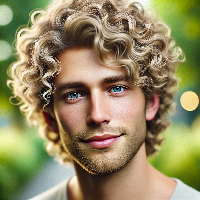

In [67]:
prepared_image

In [62]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

In [63]:
tf_image  = train_transforms(prepared_image)

In [65]:
tf_image.shape

torch.Size([3, 200, 200])

In [69]:
tf_image[0,0,0]

tensor(-1.0733)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


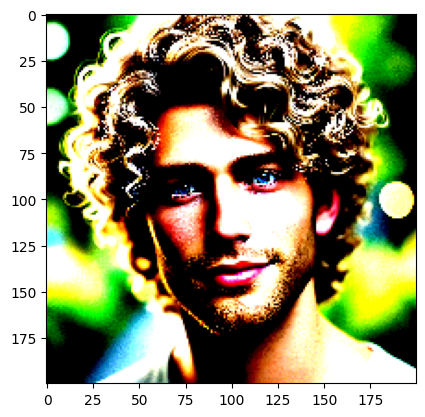

In [ ]:
transposed_image = tf_image.numpy().transpose(1, 2, 0)
plt.imshow(transposed_image)
plt.show()

In [ ]:
session = ort.InferenceSession(model_path)

Created ONNX Runtime session. Input names: ['input'], Output names: ['output']


In [79]:
image_tensor = tf_image.unsqueeze(0)

In [80]:
image_tensor.shape

torch.Size([1, 3, 200, 200])

In [ ]:
onnx_name = session.get_inputs()[0].name

'input'

In [83]:
output = session.run(None, {onnx_name: image_tensor.numpy()})
output

[array([[0.09156641]], dtype=float32)]